In [1]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)

# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.0
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu
cpu


# 数据预处理

In [2]:
# 加载FashionMNIST数据集
from torchvision import datasets, transforms

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将PIL图像或numpy数组转换为tensor,ToTensor会自动将图像转换为tensor，并归一化到[0,1]范围
    # transforms.Normalize((0.5,), (0.5,))  # 标准化到[-1, 1]范围
])

# 下载并加载训练集
train_dataset = datasets.FashionMNIST(
    root='./data',  # 数据存储路径
    train=True,     # 加载训练集
    download=True,  # 如果数据不存在则下载
    transform=transform
)

# 下载并加载测试集
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,    # 加载测试集
    download=True,
    transform=transform
)

# 打印数据集信息
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")
print(f"训练集数据类型: {type(train_dataset)}")
print(f"单个dataset元素类型: {type(train_dataset[0])}")
print(f"单个dataset元素是什么: {train_dataset[0]}")
print(f"图像尺寸: {train_dataset[0][0].shape}")
# lables在这个路径https://github.com/zalandoresearch/fashion-mnist
# FashionMNIST类别标签
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"类别数量: {len(class_names)}")
print(f"类别标签: {class_names}")


训练集大小: 60000
测试集大小: 10000
训练集数据类型: <class 'torchvision.datasets.mnist.FashionMNIST'>
单个dataset元素类型: <class 'tuple'>
单个dataset元素是什么: (tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [3]:
print(train_dataset.classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


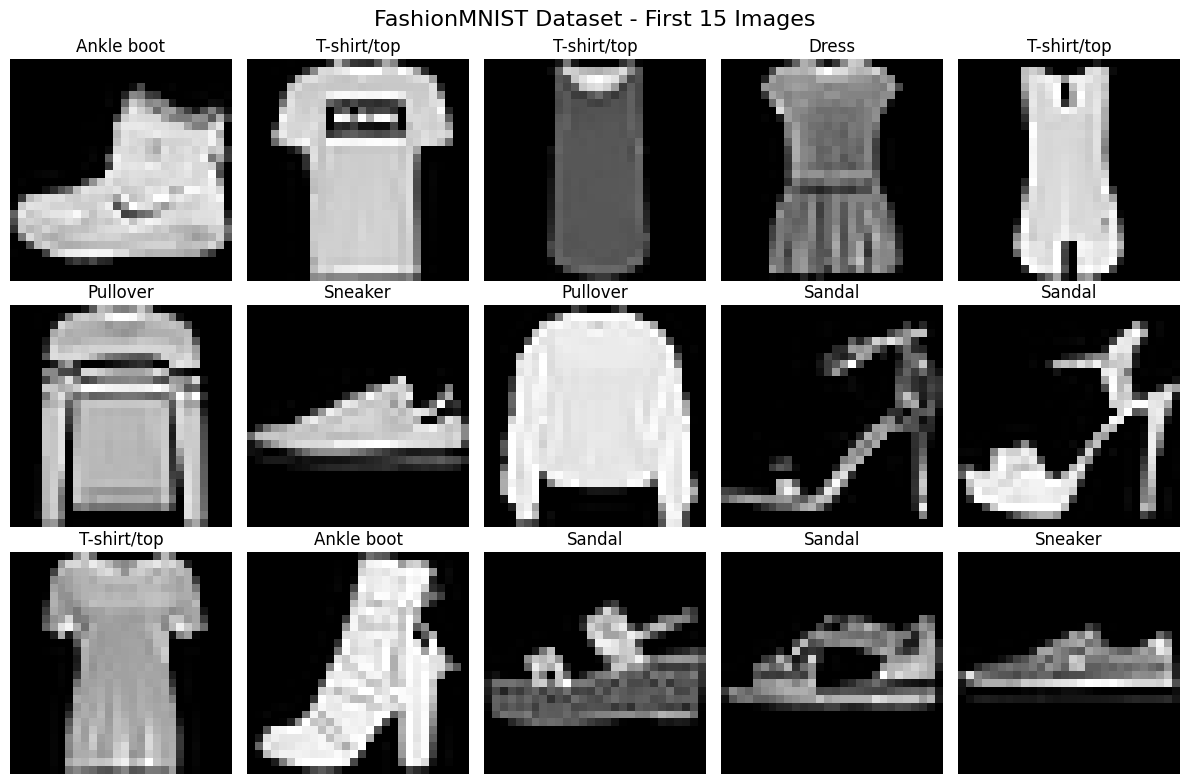

In [4]:
import matplotlib.pyplot as plt

# 显示前15张图片，每行5张，共3行
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
fig.suptitle('FashionMNIST Dataset - First 15 Images', fontsize=16)

for i in range(15):
    row = i // 5
    col = i % 5

    # 获取图像和标签
    image, label = train_dataset[i]

    # 将tensor转换为numpy数组并去掉通道维度
    image_np = image.squeeze().numpy()

    # 显示图像
    axes[row, col].imshow(image_np, cmap='gray')
    axes[row, col].set_title(f'{class_names[label]}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


In [5]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
    num_workers=2  # 使用多进程加载数据
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
    num_workers=2
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
train_iter = iter(train_loader)
batch_images, batch_labels = next(train_iter)
print(f"批次图像张量形状: {batch_images.shape}")
print(f"批次标签张量形状: {batch_labels.shape}")
print(batch_labels)

训练集DataLoader批次数: 1875
测试集DataLoader批次数: 313
每个批次大小: 32
批次图像张量形状: torch.Size([32, 1, 28, 28])
批次标签张量形状: torch.Size([32])
tensor([2, 2, 8, 4, 5, 7, 2, 1, 5, 7, 7, 9, 3, 2, 2, 8, 4, 3, 2, 9, 2, 7, 2, 6,
        8, 3, 1, 7, 4, 8, 8, 2])


In [6]:
28*28

784

在PyTorch中，`DataLoader`是一个迭代器，它封装了数据的加载和预处理过程，使得在训练机器学习模型时可以方便地批量加载数据。`DataLoader`主要负责以下几个方面：

1. **批量加载数据**：`DataLoader`可以将数据集（Dataset）切分为更小的批次（batch），每次迭代提供一小批量数据，而不是单个数据点。这有助于模型学习数据中的统计依赖性，并且可以更高效地利用GPU等硬件的并行计算能力。

2. **数据打乱**：默认情况下，`DataLoader`会在每个epoch（训练周期）开始时打乱数据的顺序。这有助于模型训练时避免陷入局部最优解，并且可以提高模型的泛化能力。

3. **多线程数据加载**：`DataLoader`支持多线程（通过参数`num_workers`）来并行地加载数据，这可以显著减少训练过程中的等待时间，尤其是在处理大规模数据集时。

4. **数据预处理**：`DataLoader`可以与`transforms`结合使用，对加载的数据进行预处理，如归一化、标准化、数据增强等操作。

5. **内存管理**：`DataLoader`负责管理数据的内存使用，确保在训练过程中不会耗尽内存资源。

6. **易用性**：`DataLoader`提供了一个简单的接口，可以很容易地集成到训练循环中。

# 搭建模型

In [5]:
import torch.nn as nn

class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        # 输入张量的形状为 (batch_size, 1, 28, 28)
        
        # 第1个卷积层：输入通道为1，输出通道为32，卷积核为3x3，padding=1保持输出尺寸不变 -> (batch, 32, 28, 28)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # 第2个卷积层：输入32通道，输出32通道（同上），不改变空间尺寸 -> (batch, 32, 28, 28)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        # 最大池化层：2x2窗口，步长为2，将空间尺寸减半 -> (batch, 32, 14, 14)
        self.pool = nn.MaxPool2d(2, 2)

        # 第3个卷积层：输入32通道，输出64通道，3x3卷积，padding=1 -> (batch, 64, 14, 14)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # 第4个卷积层：输入64通道，输出64通道，3x3卷积，padding=1 -> (batch, 64, 14, 14)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        # 再次池化，减半 -> (batch, 64, 7, 7)

        # 第5个卷积层：输入64通道，输出128通道，3x3卷积，padding=1 -> (batch, 128, 7, 7)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        # 第6个卷积层：输入128通道，输出128通道，3x3卷积，padding=1 -> (batch, 128, 7, 7)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        # 池化后 -> (batch, 128, 3, 3)

        # ReLU激活函数，高效地引入非线性，参数inplace=True节省内存
        self.relu = nn.ReLU(inplace=True)
        # 张量展平成一维，准备进入全连接层
        self.flatten = nn.Flatten()
        # 第1个全连接层：输入128*3*3（前一层展平后的长度），输出128个特征
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        # 第2个全连接层：输出类别数为10，对应FashionMNIST的10个类别
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # 前向传播定义
        # 第一组卷积 + ReLU
        x = self.relu(self.conv1(x))  # 形状: (batch, 32, 28, 28)
        x = self.relu(self.conv2(x))  # 形状: (batch, 32, 28, 28)
        x = self.pool(x)              # 形状: (batch, 32, 14, 14)

        # 第二组卷积 + ReLU
        x = self.relu(self.conv3(x))  # 形状: (batch, 64, 14, 14)
        x = self.relu(self.conv4(x))  # 形状: (batch, 64, 14, 14)
        x = self.pool(x)              # 形状: (batch, 64, 7, 7)

        # 第三组卷积 + ReLU
        x = self.relu(self.conv5(x))  # 形状: (batch, 128, 7, 7)
        x = self.relu(self.conv6(x))  # 形状: (batch, 128, 7, 7)
        x = self.pool(x)              # 形状: (batch, 128, 3, 3)

        # 展平成一维
        x = self.flatten(x)           # 形状: (batch, 128*3*3)
        # 全连接层 + ReLU
        x = self.relu(self.fc1(x))    # 形状: (batch, 128)
        # 最终分类层
        x = self.fc2(x)               # 形状: (batch, 10)
        return x

# 实例化模型
model = FashionCNN()


In [6]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 1, 28, 28)  # batch_size=1, channels=1, height=28, width=28
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [10]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
print(model.named_parameters())

for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        # .numel() 是 PyTorch 张量（Tensor）的方法，用于返回张量中元素的总数。
        # 例如：一个形状为(2,3)的张量，numel()返回6，常用来统计模型参数总数。
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
<generator object Module.named_parameters at 0x0000020DCF6A1940>
conv1.weight: 288
conv1.bias: 32
conv2.weight: 9216
conv2.bias: 32
conv3.weight: 18432
conv3.bias: 64
conv4.weight: 36864
conv4.bias: 64
conv5.weight: 73728
conv5.bias: 128
conv6.weight: 147456
conv6.bias: 128
fc1.weight: 147456
fc1.bias: 128
fc2.weight: 1280
fc2.bias: 10
模型总参数量: 435306


In [16]:
32*3*3*64

18432

# 训练

In [17]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [18]:
import wangdao_train
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=500
)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer.train(num_epochs)


[Step 500] Val Loss: 0.5322 Val Acc: 0.8076
[Step 1000] Val Loss: 0.4199 Val Acc: 0.8400
[Step 1500] Val Loss: 0.3790 Val Acc: 0.8588
Epoch [1/20]  Train Loss: 0.4875  Train Acc: 0.8186
[Step 2000] Val Loss: 0.3915 Val Acc: 0.8604
[Step 2500] Val Loss: 0.3317 Val Acc: 0.8741
[Step 3000] Val Loss: 0.3038 Val Acc: 0.8899
[Step 3500] Val Loss: 0.2926 Val Acc: 0.8926
Epoch [2/20]  Train Loss: 0.2970  Train Acc: 0.8884
[Step 4000] Val Loss: 0.3174 Val Acc: 0.8825
[Step 4500] Val Loss: 0.2807 Val Acc: 0.8974
[Step 5000] Val Loss: 0.2852 Val Acc: 0.8961
[Step 5500] Val Loss: 0.2815 Val Acc: 0.8983
Epoch [3/20]  Train Loss: 0.2473  Train Acc: 0.9073
[Step 6000] Val Loss: 0.2666 Val Acc: 0.9039
[Step 6500] Val Loss: 0.2577 Val Acc: 0.9035
[Step 7000] Val Loss: 0.2559 Val Acc: 0.9066
[Step 7500] Val Loss: 0.2565 Val Acc: 0.9080
Epoch [4/20]  Train Loss: 0.2122  Train Acc: 0.9208
[Step 8000] Val Loss: 0.2493 Val Acc: 0.9110
[Step 8500] Val Loss: 0.2368 Val Acc: 0.9110
[Step 9000] Val Loss: 0.2479

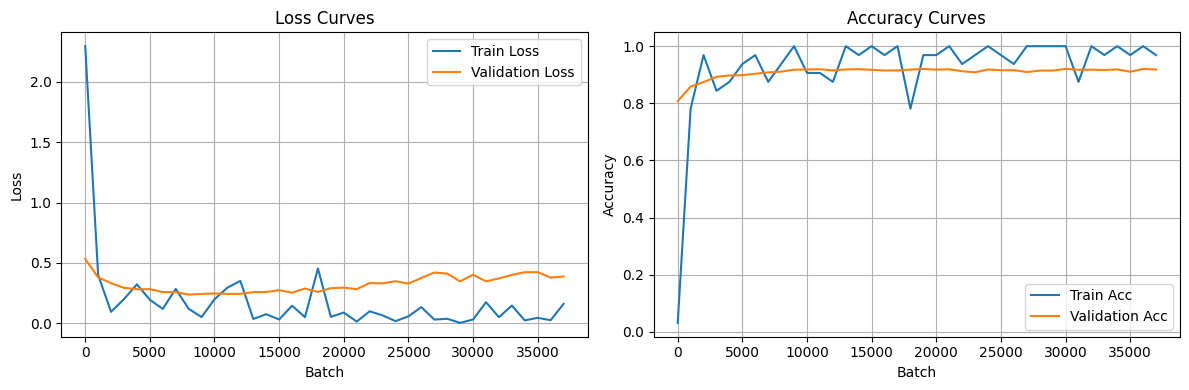

In [28]:
trainer.plot_curves()


# 标准化后重新初始化一个模型对象，训练对象

In [20]:
# 加载FashionMNIST数据集
from torchvision import datasets, transforms

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),  # 将PIL图像或numpy数组转换为tensor,ToTensor会自动将图像转换为tensor，并归一化到[0,1]范围
    # transforms.Normalize((0.2860,), (0.3205,))  # 标准化到[-1, 1]范围
])

# 下载并加载训练集
train_dataset = datasets.FashionMNIST(
    root='./data',  # 数据存储路径
    train=True,     # 加载训练集
    download=True,  # 如果数据不存在则下载
    transform=transform
)

# 下载并加载测试集
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,    # 加载测试集
    download=True,
    transform=transform
)

# 打印数据集信息
print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

# lables在这个路径https://github.com/zalandoresearch/fashion-mnist
# FashionMNIST类别标签
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(f"类别数量: {len(class_names)}")
print(f"类别标签: {class_names}")


训练集大小: 60000
测试集大小: 10000
类别数量: 10
类别标签: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [21]:
import torch  # 导入PyTorch库

# 计算整个训练集的均值和标准差
loader = torch.utils.data.DataLoader(train_dataset, batch_size=5000, shuffle=False, num_workers=0)  # 构建数据加载器，一次加载5000张图片
n_samples = 0  # 初始化样本数量
mean = 0.0     # 初始化均值
std = 0.0      # 初始化标准差

for images, _ in loader:  # 遍历数据加载器，每个batch返回(images, labels)
    # images: [batch_size, 1, 28, 28]
    batch_samples = images.size(0)  # 当前batch的图片张数
    images = images.view(batch_samples, -1)  # 展平图片为二维，方便计算，[batch_size, 784]
    mean += images.mean(1).sum()    # 计算每张图片的均值后求和，累加到总均值
    std += images.std(1).sum()      # 计算每张图片的标准差后求和，累加到总标准差
    n_samples += batch_samples      # 累加样本数量

mean /= n_samples  # 求所有图片均值的均值
std /= n_samples   # 求所有图片标准差的均值

print(f"训练集均值: {mean.item():.4f}")      # 打印训练集的均值
print(f"训练集标准差: {std.item():.4f}")     # 打印训练集的标准差


训练集均值: 0.2860
训练集标准差: 0.3205


In [22]:
mean = 0.
std = 0.
n_pixels = 0

for images, _ in loader:
    # images: [B, 1, 28, 28]
    batch_pixels = images.numel()  # B * 1 * 28 * 28
    mean += images.sum()
    std  += (images ** 2).sum()
    n_pixels += batch_pixels

mean /= n_pixels
std = torch.sqrt(std / n_pixels - mean ** 2)

print(mean.item(), std.item())


0.28604063391685486 0.3530242443084717


In [23]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
    num_workers=2  # 使用多进程加载数据
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
    num_workers=2
)

In [24]:
import torch.nn as nn

class TwoLayerNN(nn.Module):
    def __init__(self):
        super(TwoLayerNN, self).__init__()
        self.flatten = nn.Flatten() # 展平操作，将28*28的图像展平为784维的向量
        self.fc1 = nn.Linear(28*28, 300) # 全连接层，将784维的向量映射为300维的向量
        self.relu1 = nn.ReLU() # 激活函数，ReLU函数
        self.fc2 = nn.Linear(300, 100) # 全连接层，将300维的向量映射为100维的向量
        self.relu2 = nn.ReLU() # 激活函数，ReLU函数
        self.fc3 = nn.Linear(100, 10) # 全连接层，将100维的向量映射为10维的向量

    def forward(self, x):
        x = self.flatten(x)

        x = self.fc1(x)

        x = self.relu1(x)

        x = self.fc2(x)

        x = self.relu2(x)

        x = self.fc3(x)

        return x

model_normalize = TwoLayerNN()
print(model_normalize)


TwoLayerNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


In [25]:
model_normalize.state_dict()

OrderedDict([('fc1.weight',
              tensor([[ 0.0165,  0.0095,  0.0112,  ...,  0.0269, -0.0171,  0.0354],
                      [ 0.0336,  0.0312,  0.0004,  ..., -0.0079,  0.0107,  0.0296],
                      [ 0.0139, -0.0181, -0.0033,  ...,  0.0220, -0.0154, -0.0232],
                      ...,
                      [-0.0313,  0.0084, -0.0083,  ...,  0.0119,  0.0148, -0.0353],
                      [-0.0138, -0.0242,  0.0090,  ..., -0.0275,  0.0167, -0.0291],
                      [ 0.0261,  0.0142, -0.0340,  ..., -0.0179, -0.0243, -0.0262]])),
             ('fc1.bias',
              tensor([-1.9733e-02,  1.6514e-02, -1.1910e-03,  1.0991e-02, -2.1651e-02,
                      -2.4981e-02,  1.4105e-02, -3.9016e-03, -1.1525e-02, -2.9280e-03,
                      -2.1551e-02,  1.3722e-02, -2.8950e-02,  6.5651e-03,  1.1076e-02,
                       5.0341e-03,  2.5169e-02,  1.5508e-02,  3.2460e-02, -1.8127e-03,
                       3.3932e-02,  1.2078e-02,  5.7024e-03, -1.

In [26]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer_normalize = optim.SGD(model_normalize.parameters(), lr=0.001)

In [27]:
import wangdao_train
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer_normalize = wangdao_train.Trainer(
    model=model_normalize,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer_normalize,
    device=device
)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer_normalize.train(num_epochs)


[Step 100] Val Loss: 2.2908 Val Acc: 0.1041
[Step 200] Val Loss: 2.2808 Val Acc: 0.1308
[Step 300] Val Loss: 2.2710 Val Acc: 0.1905
[Step 400] Val Loss: 2.2613 Val Acc: 0.2327
[Step 500] Val Loss: 2.2516 Val Acc: 0.2723
[Step 600] Val Loss: 2.2418 Val Acc: 0.3160
[Step 700] Val Loss: 2.2313 Val Acc: 0.3319
[Step 800] Val Loss: 2.2207 Val Acc: 0.3347
[Step 900] Val Loss: 2.2093 Val Acc: 0.3704
[Step 1000] Val Loss: 2.1973 Val Acc: 0.3744
[Step 1100] Val Loss: 2.1845 Val Acc: 0.3920
[Step 1200] Val Loss: 2.1711 Val Acc: 0.4031
[Step 1300] Val Loss: 2.1562 Val Acc: 0.4196
[Step 1400] Val Loss: 2.1402 Val Acc: 0.4213
[Step 1500] Val Loss: 2.1231 Val Acc: 0.4390
[Step 1600] Val Loss: 2.1049 Val Acc: 0.4389
[Step 1700] Val Loss: 2.0851 Val Acc: 0.4591
[Step 1800] Val Loss: 2.0646 Val Acc: 0.4709
Epoch [1/20]  Train Loss: 2.1941  Train Acc: 0.3383
[Step 1900] Val Loss: 2.0423 Val Acc: 0.4920
[Step 2000] Val Loss: 2.0183 Val Acc: 0.4995
[Step 2100] Val Loss: 1.9935 Val Acc: 0.5179
[Step 2200] 

KeyboardInterrupt: 

In [ ]:
trainer_normalize.plot_curves()